<a href="https://colab.research.google.com/github/paytongagne/ADS/blob/main/Copy_of_INET4062_Module4_Homework_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INET 4062 — Data Science II  
## Week 4 Homework: Decision Trees as Reasoning Systems  


## Role  

You are a data scientist supporting **Regulatory Compliance** at a health insurance provider.


## Scenario  

Regulators and customers require explanations for automated coverage decisions. You have been asked to assess whether **decision tree models** can provide interpretable logic while maintaining acceptable predictive performance.


## Purpose of This Assignment  

This homework reinforces the Week 4 lecture on:

- Decision trees as rule-based reasoning systems  
- Tree-specific overfitting risks and complexity control  
- Comparing unconstrained vs constrained trees using evaluation discipline  
- Interpreting a decision path for explainability  
- Visualization to diagnose bias–variance behavior and model complexity  

You are not trying to “maximize accuracy.”  
You are demonstrating that you can build, compare, and interpret tree models responsibly.


## Data Context  

Assume you are given a cleaned dataset containing:

- A mix of numeric and categorical predictors describing a coverage decision context  
- A binary target variable (example name used below):  
  `coverage_approved`  
  - 1 = approved  
  - 0 = denied  

Use the same train/test boundary discipline used in lecture.


## Homework Questions  


## Teaching Focus (Read Before Answering)

The lecture emphasizes that decision trees are interpretable because they represent decisions as **explicit if/then rules**. This makes them attractive in regulated settings, but trees can easily overfit without constraints. The goal is to compare an unconstrained tree to a constrained tree and defend your conclusions using evaluation evidence.


### Question 1 — Decision Trees vs Linear Models (Conceptual)

**Question 1:**  
Explain how decision trees “reason” about predictions compared to linear models. In your answer, reference how trees use splits and paths, and how linear models use weighted combinations.

**Answer:**
Decision trees reason by asking a sequence of if/then questions (splits) on features. A prediction is produced by following one path from the root to a leaf, where the leaf stores the class (or probability) for cases that match those rules. Linear models instead compute a single weighted sum of all features (plus an intercept) and map that score to a prediction, so every feature contributes simultaneously.


## Teaching Focus (Read Before Answering)

The lecture highlights that decision trees are high-variance learners: when allowed to grow freely, they can memorize training patterns, including noise. Regulated use cases require you to identify tree-specific overfitting risks and apply constraints that make model behavior stable and explainable.


### Question 2 — Overfitting Risks Specific to Trees (Conceptual)

**Question 2:**  
Identify three overfitting risks specific to decision trees and explain why they occur.

**Answer:**
1) **Deep growth (many splits):** an unconstrained tree can keep splitting until leaves contain very few samples, which fits noise and quirks in the training set.
2) **High sensitivity to data changes:** small changes in the training data can change early splits, creating a very different tree (high variance).
3) **Overfitting to rare categories/outliers:** trees can create branches for uncommon categorical levels or extreme numeric values, producing rules that do not generalize.


## Teaching Focus (Read Before Answering)

The lecture’s modeling discipline requires you to:  
(1) establish a baseline model,  
(2) respect the train/test boundary, and  
(3) evaluate using the same metric consistently across comparisons.  
This week uses decision trees as the baseline interpretability model.


### Question 3 — Train an Unconstrained Decision Tree (Python)

**Question 3:**  
Train an **unconstrained** decision tree classifier and report train/test performance.

**Answer:**

In [ ]:
# This code loads and preprocesses the Adult Income dataset from the UCI repository.
# It demonstrates how to import data, assign column names, create a binary target variable,
# and perform stratified sampling to balance the dataset for instructional purposes.
# The final output shows a preview and summary statistics of the processed data.

import pandas as pd  # Import pandas library for data manipulation

# ------------------------------------------------------------
# Load Adult Income dataset (UCI)
# ------------------------------------------------------------
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"  # URL of the dataset

# Define column names for the dataset as it has no header row
columns = [  # List of column names corresponding to the dataset features
    "age", "workclass", "fnlwgt", "education", "education_num",  # Include demographic and work-related attributes
    "marital_status", "occupation", "relationship", "race", "sex",  # Add marital status, occupation, and relationship details
    "capital_gain", "capital_loss", "hours_per_week",  # Include race, sex, and financial information
    "native_country", "income"  # Add native country and income class label
]

# Read the dataset from the URL, assign column names, and strip leading spaces
df = pd.read_csv(url, header=None, names=columns, skipinitialspace=True)  # Load data into a DataFrame with specified columns and clean whitespace

# ------------------------------------------------------------
# Define target variable (proxy for coverage approval)
# ------------------------------------------------------------
# Create a new binary column 'coverage_approved' where income >50K is 1, else 0
df["coverage_approved"] = (df["income"] == ">50K").astype(int)  # Create binary target: 1 if income >50K, else 0

# Remove the original 'income' column as it is now redundant
df = df.drop(columns=["income"])  # Drop original income column to avoid redundancy

# ------------------------------------------------------------
# Stratified subsample for instructional performance
# ------------------------------------------------------------
# Sample 3000 rows from each class in 'coverage_approved' to balance the dataset
df = df.groupby("coverage_approved", group_keys=False).sample(  # Perform stratified sampling to maintain class balance
    n=3000,  # Number of samples per group
    random_state=42  # Seed for reproducibility
)

# Display the first few rows and summary statistics of the processed dataframe
df.head(), df.describe()  # Show preview and statistical summary of the processed data


(       age         workclass  fnlwgt     education  education_num  \
 3326    32           Private   43403  Some-college             10   
 26225   19                 ?  182609       HS-grad              9   
 6130    51           Private  332243     Bachelors             13   
 2211    27           Private  158156       HS-grad              9   
 12946   64  Self-emp-not-inc  170421  Some-college             10   
 
       marital_status       occupation   relationship   race     sex  \
 3326        Divorced  Farming-fishing  Not-in-family  White  Female   
 26225  Never-married                ?      Own-child  Black  Female   
 6130        Divorced   Prof-specialty  Not-in-family  White    Male   
 2211   Never-married    Other-service  Not-in-family  White  Female   
 12946        Widowed     Craft-repair  Not-in-family  White  Female   
 
        capital_gain  capital_loss  hours_per_week native_country  \
 3326              0          1590              54  United-States   
 26225

In [ ]:
# # This code demonstrates a complete machine learning workflow using a decision tree classifier.
# It includes data splitting, preprocessing pipelines for numeric and categorical features,
# model training, prediction, and evaluation of accuracy on both training and test sets.
# The goal is to illustrate how to build and evaluate a pipeline for classification tasks.

from sklearn.model_selection import train_test_split  # For splitting data into train and test sets
from sklearn.compose import ColumnTransformer          # For applying different preprocessing to columns
from sklearn.pipeline import Pipeline                   # For chaining preprocessing and modeling steps
from sklearn.preprocessing import OneHotEncoder        # For encoding categorical variables
from sklearn.impute import SimpleImputer                # For handling missing values
from sklearn.tree import DecisionTreeClassifier         # The classification model
from sklearn.metrics import accuracy_score              # For evaluating model accuracy

RANDOM_STATE = 42  # Set random seed for reproducibility

# -----------------------------
# Define features and target
# -----------------------------
y = df["coverage_approved"]  # Target variable to predict
X = df.drop(columns=["coverage_approved"])  # Feature matrix excluding target column

# -----------------------------
# Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

# -----------------------------
# Preprocessing (categorical + numeric)
# -----------------------------
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Pipeline for numeric features: impute missing values with median
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Pipeline for categorical features: impute missing with most frequent and one-hot encode
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numeric and categorical pipelines into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# -----------------------------
# Unconstrained tree
# -----------------------------
tree_unconstrained = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Train model on training data
tree_unconstrained.fit(X_train, y_train)

pred_train = tree_unconstrained.predict(X_train)
pred_test = tree_unconstrained.predict(X_test)

acc_train = accuracy_score(y_train, pred_train)
acc_test = accuracy_score(y_test, pred_test)

acc_train, acc_test


(1.0, 0.7526666666666667)


## Teaching Focus (Read Before Answering)

The lecture emphasizes that constraints exist to reduce variance and improve generalization. Constraining a tree is not “making it worse,” it is enforcing stability and interpretability. You should apply constraints directly via model parameters.


### Question 4 — Train a Constrained Tree Using Lecture Parameters (Python)

**Question 4:**
Train a constrained decision tree using lecture-aligned parameters (example: `max_depth`, `min_samples_leaf`) and report train/test performance.

**Answer:**

In [ ]:
# # This code demonstrates how to create, train, and evaluate a constrained decision tree classifier using a pipeline.
# It includes preprocessing, model training with hyperparameters to prevent overfitting, and accuracy calculation.
# The goal is to show how to integrate preprocessing and model training, then assess performance on training and test sets.

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Define a pipeline combining preprocessing and a constrained decision tree model
tree_constrained = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        random_state=RANDOM_STATE
    ))
])

tree_constrained.fit(X_train, y_train)
pred_train_c = tree_constrained.predict(X_train)
pred_test_c = tree_constrained.predict(X_test)

acc_train_c = accuracy_score(y_train, pred_train_c)
acc_test_c = accuracy_score(y_test, pred_test_c)

acc_train_c, acc_test_c


(0.8053333333333333, 0.798)


## Teaching Focus (Read Before Answering)

Tree comparisons should be made using the same evaluation approach. The key signal of overfitting is a large train/test gap, while improved generalization appears as a reduced gap even if training accuracy decreases.


### Question 5 — Compare Train/Test Performance Across Both Trees (Python)

**Question 5:**
Compare training and test performance for the unconstrained vs constrained tree and summarize the result.

**Answer:**

In [ ]:
# This code block creates a dictionary to store and organize model evaluation metrics.
# It captures training and testing accuracies for both unconstrained and constrained trees.
# Additionally, it calculates the accuracy gaps between training and testing for both models.
# This structured results dictionary helps in comparing model performance clearly.

results = {
    "unconstrained_tree": {"train_accuracy": acc_train, "test_accuracy": acc_test},  # Store accuracies for unconstrained tree
    "constrained_tree": {"train_accuracy": acc_train_c, "test_accuracy": acc_test_c},  # Store accuracies for constrained tree
    "gap_unconstrained": acc_train - acc_test,
"gap_constrained": acc_train_c - acc_test_c}

results  # Display the results dictionary to review stored metrics


{'unconstrained_tree': {'train_accuracy': 1.0,
  'test_accuracy': 0.7526666666666667},
 'constrained_tree': {'train_accuracy': 0.8053333333333333,
  'test_accuracy': 0.798},
 'gap_unconstrained': 0.2473333333333333,
 'gap_constrained': 0.007333333333333303}

**Interpretation:**
If the unconstrained tree has much higher training accuracy than test accuracy, that indicates high variance (overfitting). If the constrained tree reduces the gap and maintains reasonable test accuracy, it is more defensible for regulated decisioning.


## Teaching Focus (Read Before Answering)

The lecture emphasizes that trees support interpretability because you can trace a single prediction through a sequence of rules. Compliance contexts require you to communicate model logic clearly and defensibly, not just provide a score.


### Question 6 — Interpret One Decision Path From the Constrained Tree (Python)

**Question 6:**
Interpret one decision path from the constrained tree for a single test record.

**Answer:**

In [ ]:
# This code extracts and displays the decision rules from a fitted decision tree model
# inside a pipeline. It demonstrates how to access the model and feature names after
# preprocessing, and then exports the tree structure as readable text rules.

from sklearn.tree import export_text
import numpy as np

# Extract the fitted decision tree model from the pipeline's named steps
tree_model = tree_constrained.named_steps["classifier"]

# Retrieve the feature names after preprocessing (including one-hot encoded features)
feature_names = tree_constrained.named_steps["preprocessor"].get_feature_names_out()

# Export the decision tree rules as a text string using the feature names
from sklearn.tree import export_text

rules = export_text(tree_model, feature_names=list(feature_names))
print(rules)
# Display the first 2000 characters of the exported rules for inspection
rules[:2000]


|--- cat__marital_status_Married-civ-spouse <= 0.50
|   |--- num__capital_gain <= 4668.50
|   |   |--- num__education_num <= 12.50
|   |   |   |--- num__capital_loss <= 2218.50
|   |   |   |   |--- num__hours_per_week <= 42.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__hours_per_week >  42.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- num__capital_loss >  2218.50
|   |   |   |   |--- class: 1
|   |   |--- num__education_num >  12.50
|   |   |   |--- num__age <= 30.50
|   |   |   |   |--- num__capital_loss <= 1328.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__capital_loss >  1328.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- num__age >  30.50
|   |   |   |   |--- num__education_num <= 14.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__education_num >  14.50
|   |   |   |   |   |--- class: 1
|   |--- num__capital_gain >  4668.50
|   |   |--- num__capital_gain <= 7669.50
|   |   |   |--- num__capital_gain <= 5194.50
|   |   

'|--- cat__marital_status_Married-civ-spouse <= 0.50\n|   |--- num__capital_gain <= 4668.50\n|   |   |--- num__education_num <= 12.50\n|   |   |   |--- num__capital_loss <= 2218.50\n|   |   |   |   |--- num__hours_per_week <= 42.50\n|   |   |   |   |   |--- class: 0\n|   |   |   |   |--- num__hours_per_week >  42.50\n|   |   |   |   |   |--- class: 0\n|   |   |   |--- num__capital_loss >  2218.50\n|   |   |   |   |--- class: 1\n|   |   |--- num__education_num >  12.50\n|   |   |   |--- num__age <= 30.50\n|   |   |   |   |--- num__capital_loss <= 1328.00\n|   |   |   |   |   |--- class: 0\n|   |   |   |   |--- num__capital_loss >  1328.00\n|   |   |   |   |   |--- class: 1\n|   |   |   |--- num__age >  30.50\n|   |   |   |   |--- num__education_num <= 14.50\n|   |   |   |   |   |--- class: 0\n|   |   |   |   |--- num__education_num >  14.50\n|   |   |   |   |   |--- class: 1\n|   |--- num__capital_gain >  4668.50\n|   |   |--- num__capital_gain <= 7669.50\n|   |   |   |--- num__capital_

In [ ]:
# This code selects a single test instance and traces its decision path through a trained decision tree model.
# It demonstrates how to extract the sequence of decision nodes visited for that instance,
# interpret the splitting conditions at each node, and summarize the path as human-readable rules.
# This is useful for understanding model predictions and explaining individual decisions.

x_one = X_test.iloc[[0]]  # Select the first test instance as a DataFrame
x_one_transformed = tree_constrained.named_steps["preprocessor"].transform(x_one)

decision_path = tree_model.decision_path(x_one_transformed)
node_indicator = decision_path
leaf_id = tree_model.apply(x_one_transformed)

node_index = decision_path.indices
node_index
path_explanation = []  # Initialize list to store human-readable path explanations
for node_id in node_index:
    if leaf_id[0] == node_id:
        continue
    feature_id = tree_model.tree_.feature[node_id]
    threshold = tree_model.tree_.threshold[node_id]
    feature_name = feature_names[feature_id]
    value = x_one_transformed[0, feature_id]

    direction = "≤" if value <= threshold else ">"
    path_explanation.append(f"{feature_name}: {value:.4f} {direction} {threshold:.4f}")

path_explanation


['cat__marital_status_Married-civ-spouse: 1.0000 > 0.5000',
 'num__education_num: 14.0000 > 9.5000',
 'num__capital_gain: 15024.0000 > 4225.0000']

**Interpretation:**
This path is the explicit rule chain the model used to produce its prediction. This form of reasoning is valuable in compliance because it supports auditability, dispute handling, and defensible explanations.


## Teaching Focus (Read Before Answering)

The lecture emphasizes that visualization is not “extra.” It provides evidence for bias–variance behavior, learned decision structure, and the effect of complexity control. The visual outputs below must support your conclusions.


### Question 7 — Visualization (Python)

**Question 7:**
Create the required visualizations:

* Tree depth vs training/testing accuracy
* Feature importance bar plot
* Cost-complexity pruning curve

**Answer:**

#### A) Tree Depth vs Training/Testing Accuracy

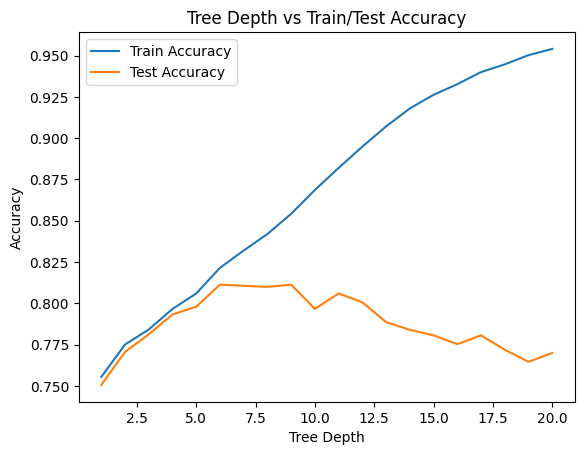

In [ ]:
# This code evaluates the effect of decision tree depth on model accuracy.
# It trains decision trees with depths from 1 to 20, records train/test accuracy,
# and plots accuracy curves to visualize potential overfitting or underfitting.
# This helps students understand model complexity and performance trade-offs.

import matplotlib.pyplot as plt  # Import plotting library for visualization
import numpy as np  # Import numpy for numerical operations (not directly used here)
from sklearn.metrics import accuracy_score  # Import accuracy metric for evaluation
from sklearn.tree import DecisionTreeClassifier  # Import decision tree classifier

depths = list(range(1, 21))  # Define a list of tree depths from 1 to 20
train_accs = []  # Initialize list to store training accuracies
test_accs = []  # Initialize list to store testing accuracies

for d in depths:  # Loop over each tree depth
    model = Pipeline([  # Create a pipeline combining preprocessing and model
        ("preprocessor", preprocessor),  # Apply preprocessing steps (assumed defined)
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=d))  # Decision tree with max depth d
    ])
    model.fit(X_train, y_train)  # Train the model on training data
    train_accs.append(accuracy_score(y_train, model.predict(X_train)))  # Compute and store train accuracy
    test_accs.append(accuracy_score(y_test, model.predict(X_test)))  # Compute and store test accuracy

plt.plot(depths, train_accs, label="Train Accuracy")  # Plot training accuracy vs depth
plt.plot(depths, test_accs, label="Test Accuracy")  # Plot testing accuracy vs depth
plt.xlabel("Tree Depth")  # Label x-axis
plt.ylabel("Accuracy")  # Label y-axis
plt.title("Tree Depth vs Train/Test Accuracy")  # Add plot title
plt.legend()  # Show legend to distinguish lines
plt.show()  # Display the plot


#### B) Feature Importance Bar Plot (Constrained Tree)

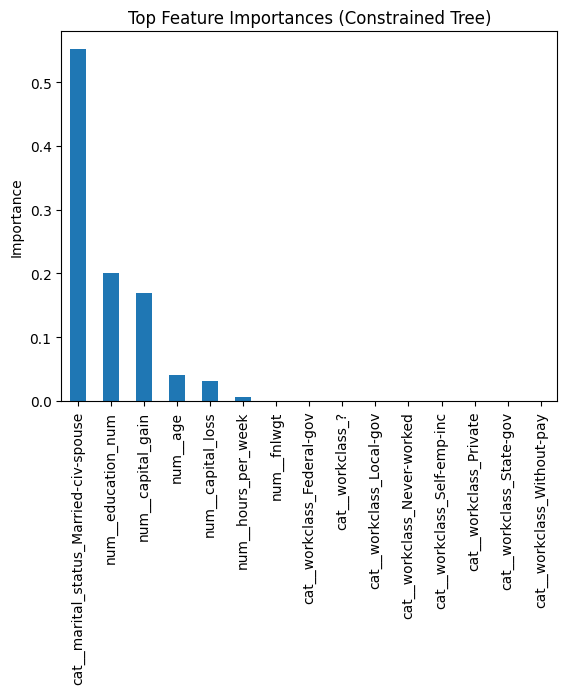

In [ ]:
# This code snippet demonstrates how to extract and visualize the top feature importances from a trained decision tree model.
# It uses pandas to organize the importance scores, sorts them to identify the most influential features,
# and then plots these top features using matplotlib for easy interpretation.
# This is useful for understanding which features contribute most to the model's decisions.

import pandas as pd  # Import pandas for data manipulation
import matplotlib.pyplot as plt  # Import matplotlib for plotting
import numpy as np  # Import numpy for numerical operations (not directly used here but often needed)

importances = tree_model.feature_importances_  # Extract feature importance scores from the trained tree model
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)  # Create a Series with feature names as index, sort descending, and select top 15

fi.plot(kind="bar")  # Plot the top 15 feature importances as a bar chart
plt.title("Top Feature Importances (Constrained Tree)")  # Add a title to the plot
plt.ylabel("Importance")  # Label the y-axis to indicate importance scores
plt.show()  # Display the plot to the user


#### C) Cost-Complexity Pruning Curve

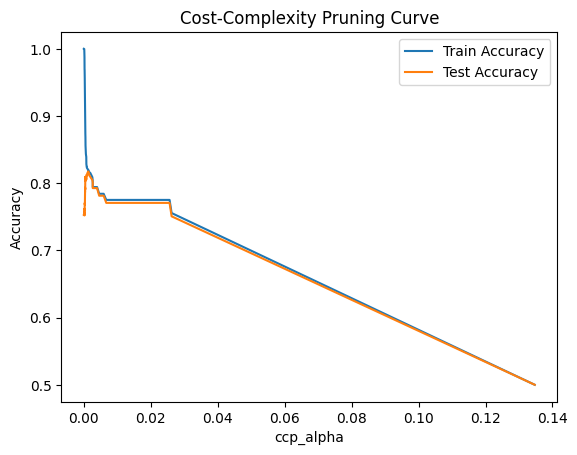

In [ ]:
# # This code demonstrates how to perform cost-complexity pruning on a decision tree.
# It fits a decision tree on preprocessed training data, obtains pruning paths,
# and evaluates accuracy for different pruning levels on both training and test sets.
# Finally, it plots the accuracy curves to visualize the effect of pruning.

from sklearn.tree import DecisionTreeClassifier  # Import DecisionTreeClassifier

X_train_proc = preprocessor.fit_transform(X_train)  # Preprocess training data
X_test_proc = preprocessor.transform(X_test)  # Preprocess test data

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)  # Base decision tree model
path = dt.cost_complexity_pruning_path(X_train_proc, y_train)  # Compute pruning path
ccp_alphas = path.ccp_alphas  # Extract pruning alpha values

train_scores = []  # Store training accuracies
test_scores = []  # Store test accuracies

for a in ccp_alphas:  # Iterate over pruning levels
    dt_pruned = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=a)  # Pruned tree
    dt_pruned.fit(X_train_proc, y_train)  # Train pruned tree
    train_scores.append(dt_pruned.score(X_train_proc, y_train))  # Training accuracy
    test_scores.append(dt_pruned.score(X_test_proc, y_test))  # Test accuracy

plt.plot(ccp_alphas, train_scores, label="Train Accuracy")  # Plot train accuracy
plt.plot(ccp_alphas, test_scores, label="Test Accuracy")  # Plot test accuracy
plt.xlabel("ccp_alpha")  # X-axis label
plt.ylabel("Accuracy")  # Y-axis label
plt.title("Cost-Complexity Pruning Curve")  # Plot title
plt.legend()  # Show legend
plt.show()  # Display plot


**Interpretation:**

* Depth vs accuracy shows where variance increases (train rises while test falls).
* Feature importance shows which variables dominate decisions and supports explainability.
* Pruning curves show how complexity control can improve test performance by removing overfit structure.


## Submission Instructions

* Submit a single Jupyter Notebook (`.ipynb`)
* Include outputs for:

  * unconstrained vs constrained train/test accuracy (Q3–Q5)
  * decision path interpretation output (Q6)
  * tree depth curve, feature importance plot, and pruning curve (Q7)
* Do **not** tune beyond lecture parameters
  (the focus is interpretability and disciplined comparison, not optimization)